# Actividad: Mapas Coropléticos de Migración en la Región Metropolitana — SOLUCIÓN

**Curso: Análisis de Datos Espaciales con Python**  
**Duración: 1 hora (máximo)**

---

## Contexto

En la clase anterior aprendimos a construir **mapas coropléticos** usando datos del PIB per cápita de México: cómo clasificar una variable continua en categorías discretas y pintar cada polígono según su clase.

Hoy aplicamos esas mismas técnicas a la **migración internacional en la Región Metropolitana de Chile**, usando datos del **Censo de Población y Vivienda 2024** publicados por el INE.

### Prerrequisito

Ejecutar primero `03_actividad3_preambulo.ipynb` o tener listo el archivo `migrant_reg_counts.csv` en `datos/external/censo2024/personas/`.


---
## PARTE 1: Preparación del entorno y datos (15 minutos)
### 1.1 Importar librerías


In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import mapclassify
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["figure.dpi"] = 96

### 1.2 Cargar los datos de migración


In [2]:
migrant_reg_counts = pd.read_csv('datos/external/censo2024/personas/migrant_reg_counts.csv')

print(f"Filas: {migrant_reg_counts.shape[0]}, Columnas: {migrant_reg_counts.shape[1]}")
print(f"Columnas: {migrant_reg_counts.columns.tolist()}")
migrant_reg_counts.head(10)

Filas: 653, Columnas: 4
Columnas: ['CODIGO_PAIS', 'Nº_MIGRANTES', 'CONTINENTE', 'COMUNA']


,CODIGO_PAIS,Nº_MIGRANTES,CONTINENTE,COMUNA
0,2,90,África,Santiago
1,2,4,África,Cerrillos
2,2,13,África,Cerro Navia
3,2,5,África,Conchalí
4,2,4,África,El Bosque
5,2,22,África,Estación Central
6,2,1,África,Huechuraba
7,2,31,África,Independencia
8,2,8,África,La Cisterna
9,2,24,África,La Florida


### 1.3 Agregar: total de migrantes por comuna


In [3]:
migrantes_por_comuna = migrant_reg_counts.groupby("COMUNA")["Nº_MIGRANTES"].sum().reset_index()
migrantes_por_comuna.columns = ["COMUNA", "TOTAL_MIGRANTES"]

print(f"Comunas con datos: {len(migrantes_por_comuna)}")
migrantes_por_comuna.sort_values("TOTAL_MIGRANTES", ascending=False).head(10)

Comunas con datos: 52


,COMUNA,TOTAL_MIGRANTES
47,Santiago,172692
10,Estación Central,68736
12,Independencia,50999
44,San Miguel,37661
38,Quinta Normal,35041
15,La Florida,33904
39,Recoleta,33173
51,Ñuñoa,29233
25,Maipú,28317
36,Puente Alto,26701


### 1.4 Cargar la geometría comunal


In [4]:
comunas_gdf = gpd.read_file("datos/external/censo2017/R13/COMUNA_C17.shp")

print(f"Comunas en el shapefile: {len(comunas_gdf)}")
print(f"Columnas: {comunas_gdf.columns.tolist()}")
comunas_gdf.head()

Comunas en el shapefile: 52
Columnas: ['REGION', 'NOM_REGION', 'PROVINCIA', 'NOM_PROVIN', 'COMUNA', 'NOM_COMUNA', 'SHAPE_Leng', 'SHAPE_Area', 'geometry']


,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,NOM_COMUNA,SHAPE_Leng,SHAPE_Area,geometry
0,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13404,PAINE,1.625330,0.066035,"POLYGON ((-70.61889 -33.73808, -70.61811 -33.7..."
1,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13402,BUIN,0.884164,0.021166,"POLYGON ((-70.63192 -33.64634, -70.63207 -33.6..."
2,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13124,PUDAHUEL,0.720176,0.019124,"POLYGON ((-70.78914 -33.36153, -70.78824 -33.3..."
3,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13103,CERRO NAVIA,0.170180,0.001076,"POLYGON ((-70.71927 -33.41334, -70.71888 -33.4..."
4,13,REGIÓN METROPOLITANA DE SANTIAGO,133,CHACABUCO,13301,COLINA,1.692007,0.093820,"POLYGON ((-70.59630 -32.95138, -70.59673 -32.9..."


### 1.5 Unir datos de migración con la geometría


In [5]:
print("Primeras filas del shapefile:")
print(comunas_gdf[["NOM_COMUNA"]].head(10))
print()
print("Nombres únicos en shapefile:", sorted(comunas_gdf["NOM_COMUNA"].unique())[:10], "...")
print()
print("Nombres únicos en migración:", sorted(migrantes_por_comuna["COMUNA"].unique())[:10], "...")

Primeras filas del shapefile:
    NOM_COMUNA
0        PAINE
1         BUIN
2     PUDAHUEL
3  CERRO NAVIA
4       COLINA
5       TILTIL
6        LAMPA
7   HUECHURABA
8     CONCHALÍ
9  MARÍA PINTO

Nombres únicos en shapefile: ['ALHUÉ', 'BUIN', 'CALERA DE TANGO', 'CERRILLOS', 'CERRO NAVIA', 'COLINA', 'CONCHALÍ', 'CURACAVÍ', 'EL BOSQUE', 'EL MONTE'] ...

Nombres únicos en migración: ['Alhué', 'Buin', 'Calera de Tango', 'Cerrillos', 'Cerro Navia', 'Colina', 'Conchalí', 'Curacaví', 'El Bosque', 'El Monte'] ...


In [6]:
import unicodedata

def normalizar(texto):
    if pd.isna(texto):
        return texto
    texto = str(texto).strip().upper()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    return texto

comunas_gdf["NOMBRE_NORM"] = comunas_gdf["NOM_COMUNA"].apply(normalizar)
migrantes_por_comuna["NOMBRE_NORM"] = migrantes_por_comuna["COMUNA"].apply(normalizar)

gdf = comunas_gdf.merge(migrantes_por_comuna, on="NOMBRE_NORM", how="left")

n_match = gdf["TOTAL_MIGRANTES"].notna().sum()
print(f"Comunas con datos de migración: {n_match} de {len(gdf)}")

if gdf["TOTAL_MIGRANTES"].isna().any():
    print("\nComunas SIN match (revisar nombres):")
    print(gdf.loc[gdf["TOTAL_MIGRANTES"].isna(), "NOM_COMUNA"].tolist())

Comunas con datos de migración: 52 de 52


### 1.6 Calcular el porcentaje de migrantes


In [7]:
poblacion_rm = {
    "SANTIAGO": 404000, "CERRILLOS": 88000, "CERRO NAVIA": 132000,
    "CONCHALI": 128000, "EL BOSQUE": 162000, "ESTACION CENTRAL": 178000,
    "HUECHURABA": 112000, "INDEPENDENCIA": 115000, "LA CISTERNA": 95000,
    "LA FLORIDA": 366000, "LA GRANJA": 116000, "LA PINTANA": 177000,
    "LA REINA": 88000, "LAS CONDES": 249000, "LO BARNECHEA": 124000,
    "LO ESPEJO": 96000, "LO PRADO": 94000, "MACUL": 116000,
    "MAIPU": 578000, "NUNOA": 228000, "PEDRO AGUIRRE CERDA": 95000,
    "PENALOLEN": 252000, "PROVIDENCIA": 142000, "PUDAHUEL": 265000,
    "QUILICURA": 255000, "QUINTA NORMAL": 128000, "RECOLETA": 175000,
    "RENCA": 158000, "SAN JOAQUIN": 94000, "SAN MIGUEL": 107000,
    "SAN RAMON": 82000, "VITACURA": 87000, "PUENTE ALTO": 648000,
    "SAN BERNARDO": 330000, "COLINA": 195000, "LAMPA": 130000,
    "PADRE HURTADO": 68000, "PENAFLOR": 80000, "PIRQUE": 26000,
    "TALAGANTE": 72000, "BUIN": 95000, "CALERA DE TANGO": 30000,
    "PAINE": 82000, "SAN JOSE DE MAIPO": 18000, "MELIPILLA": 110000,
    "ALHUE": 6000, "CURACAVI": 38000, "MARIA PINTO": 12000,
    "SAN PEDRO": 4000, "TILTIL": 22000, "ISLA DE MAIPO": 35000
}

gdf["POBLACION"] = gdf["NOMBRE_NORM"].map(poblacion_rm)

In [8]:
gdf["PCT_MIGRANTES"] = (gdf["TOTAL_MIGRANTES"] / gdf["POBLACION"]) * 100

print("Top 10 comunas por % de migrantes:")
gdf[["NOMBRE_NORM", "TOTAL_MIGRANTES", "POBLACION", "PCT_MIGRANTES"]].dropna().sort_values(
    "PCT_MIGRANTES", ascending=False
).head(10)

Top 10 comunas por % de migrantes:


,NOMBRE_NORM,TOTAL_MIGRANTES,POBLACION,PCT_MIGRANTES
16,INDEPENDENCIA,50999,115000.0,44.346957
47,SANTIAGO,172692,404000.0,42.745545
13,ESTACION CENTRAL,68736,178000.0,38.615730
43,SAN MIGUEL,37661,107000.0,35.197196
50,SAN PEDRO,1245,4000.0,31.125000
26,QUINTA NORMAL,35041,128000.0,27.375781
19,LA CISTERNA,19161,95000.0,20.169474
15,RECOLETA,33173,175000.0,18.956000
51,ALHUE,879,6000.0,14.650000
42,SAN JOAQUIN,13442,94000.0,14.300000


---
## PARTE 2: Exploración estadística (10 minutos)
### 2.1 Distribución de la variable


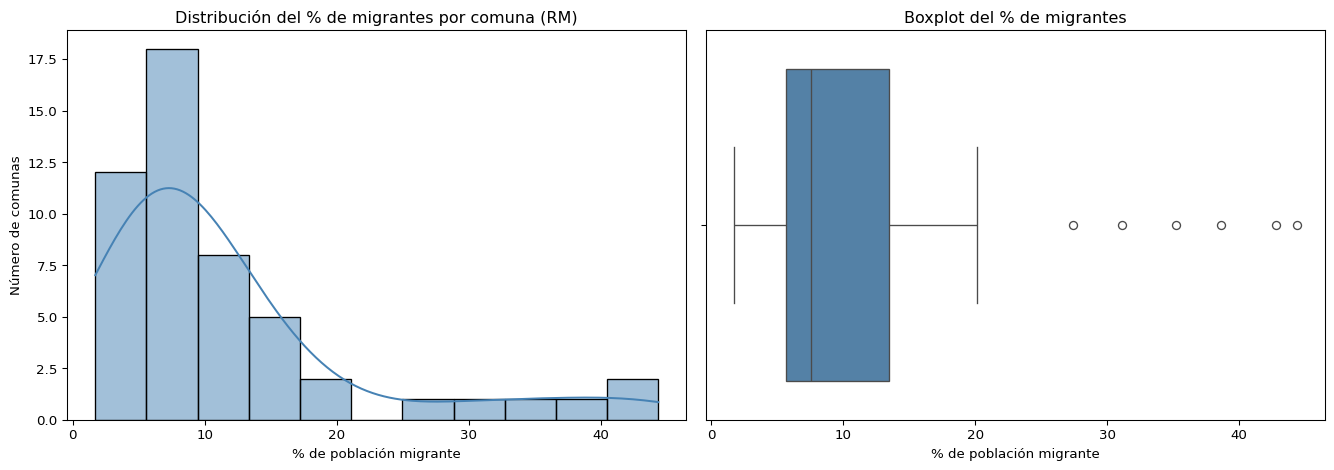

In [9]:
var = gdf["PCT_MIGRANTES"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(var, ax=axes[0], color="steelblue", kde=True)
axes[0].set_title("Distribución del % de migrantes por comuna (RM)", fontsize=12)
axes[0].set_xlabel("% de población migrante")
axes[0].set_ylabel("Número de comunas")

sns.boxplot(x=var, ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot del % de migrantes", fontsize=12)
axes[1].set_xlabel("% de población migrante")

plt.tight_layout()
plt.show()

In [10]:
print("=== Estadísticas del % de Migrantes por Comuna ===")
print(var.describe())
print()

idx_max = gdf["PCT_MIGRANTES"].idxmax()
idx_min = gdf["PCT_MIGRANTES"].idxmin()
print(f"Comuna con MAYOR % migrante: {gdf.loc[idx_max, 'NOMBRE_NORM']} ({gdf.loc[idx_max, 'PCT_MIGRANTES']:.1f}%)")
print(f"Comuna con MENOR % migrante: {gdf.loc[idx_min, 'NOMBRE_NORM']} ({gdf.loc[idx_min, 'PCT_MIGRANTES']:.1f}%)")
print(f"Mediana: {var.median():.1f}%")
print(f"Media:   {var.mean():.1f}%")
print(f"\n¿Asimetría? skewness = {var.skew():.2f}  (>0 = asimetría positiva)")

=== Estadísticas del % de Migrantes por Comuna ===
count    51.000000
mean     11.612856
std      10.255874
min       1.700000
25%       5.649725
50%       7.564368
75%      13.481947
max      44.346957
Name: PCT_MIGRANTES, dtype: float64

Comuna con MAYOR % migrante: INDEPENDENCIA (44.3%)
Comuna con MENOR % migrante: PIRQUE (1.7%)
Mediana: 7.6%
Media:   11.6%

¿Asimetría? skewness = 1.98  (>0 = asimetría positiva)


### Pregunta para reflexionar

> **Respuesta:** La distribución presenta una clara **asimetría positiva** (skewness > 0). La mayoría de las comunas tiene un porcentaje bajo de migrantes (bajo el 10%), mientras que unas pocas comunas (Independencia, Santiago, Estación Central) tienen valores mucho más altos, generando una **cola larga a la derecha**. Hay outliers visibles en el boxplot.
>
> **Predicción de clasificadores:**
> - **Intervalos Iguales** probablemente concentrará muchas comunas en la primera clase (como pasó con México), porque el ancho fijo no se adapta bien a distribuciones asimétricas.
> - **Cuantiles** repartirá las comunas de forma equilibrada, pero agrupará comunas muy diferentes en la última clase (desde ~14% hasta ~44%).
> - **Fisher-Jenks** debería encontrar el mejor equilibrio, separando bien los outliers altos.
> - **Media-Desv. Est.** sería una pésima elección (igual que con México), porque metería casi todo en una clase central.


---
## PARTE 3: Mapas coropléticos con distintos clasificadores (20 minutos)
### 3.1 Primer vistazo: el mapa sin datos


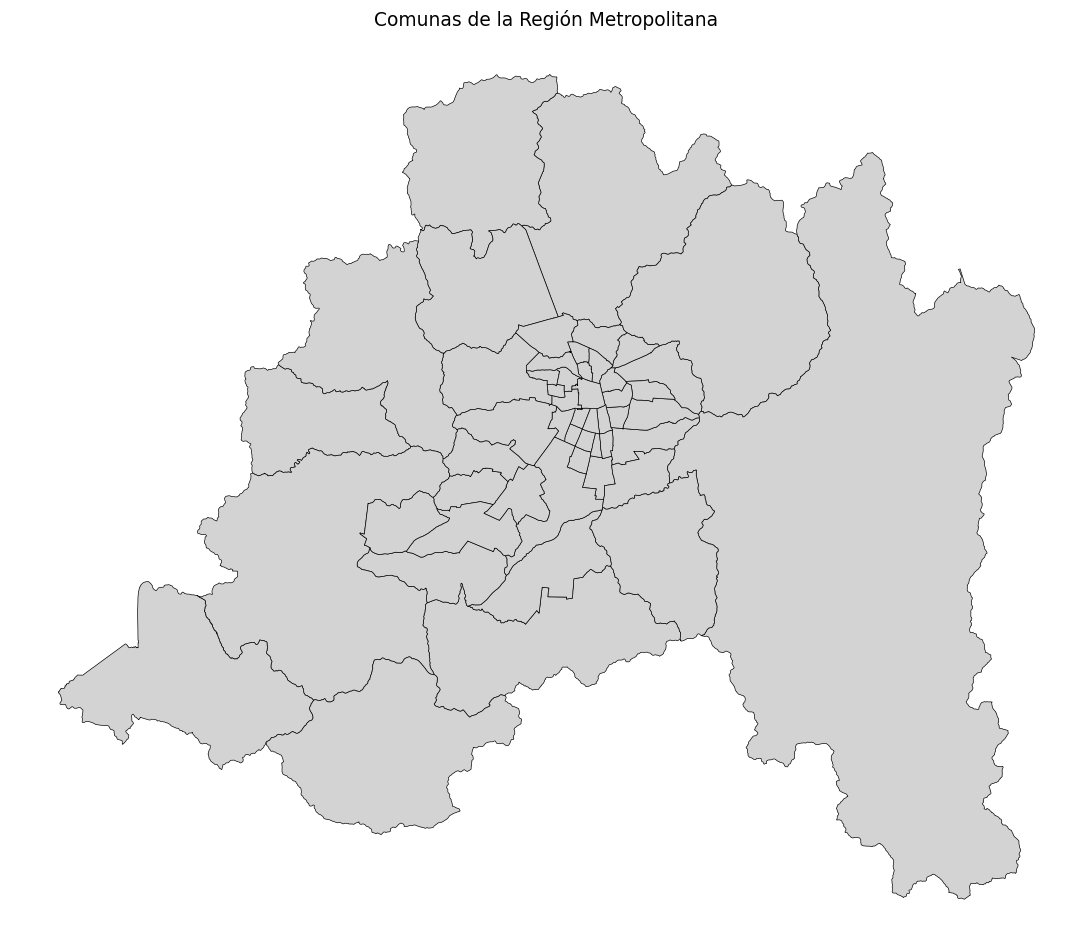

In [11]:
fig, ax = plt.subplots(1, figsize=(12, 10))
gdf.plot(ax=ax, edgecolor="black", facecolor="lightgray", linewidth=0.5)
ax.set_title("Comunas de la Región Metropolitana", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 3.2 Intervalos Iguales (k=5)


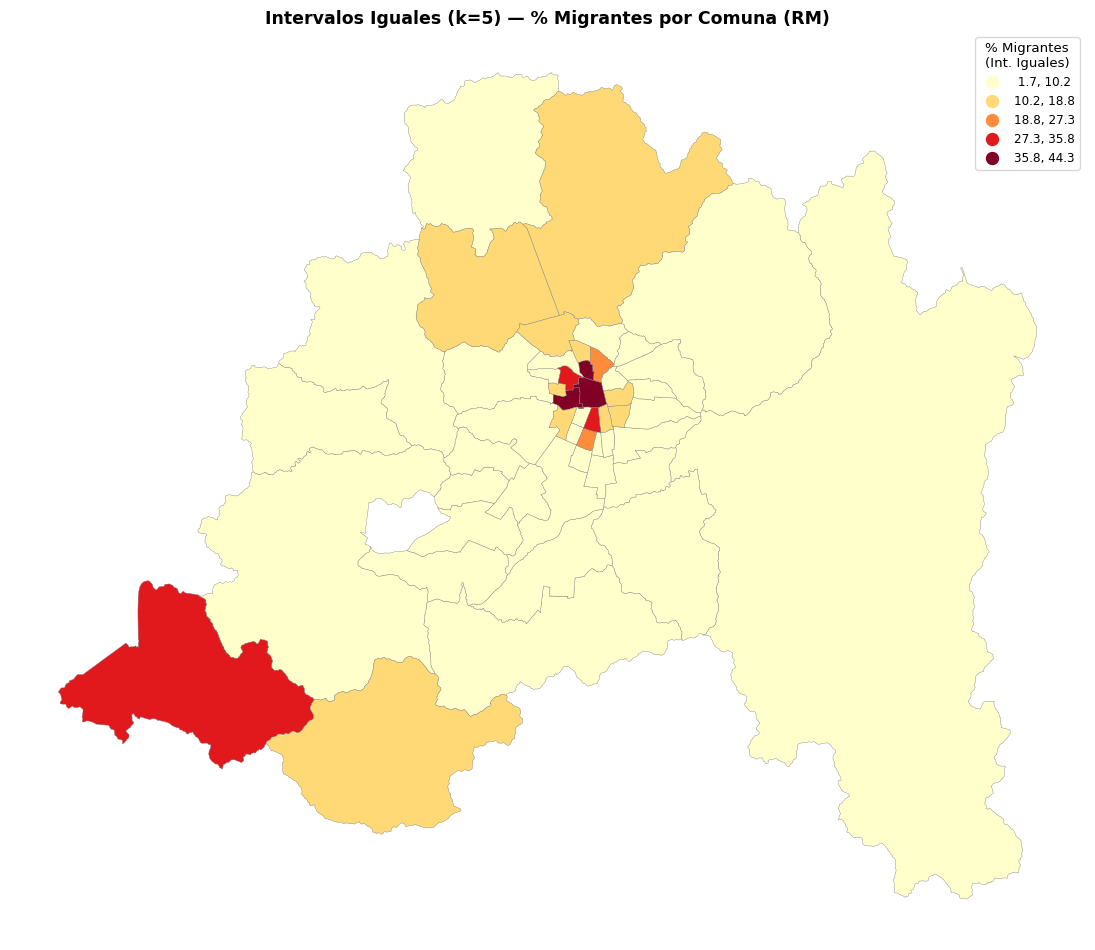

EqualInterval

   Interval      Count
----------------------
[ 1.70, 10.23] |    33
(10.23, 18.76] |    10
(18.76, 27.29] |     2
(27.29, 35.82] |     3
(35.82, 44.35] |     3


In [12]:
gdf_clean = gdf.dropna(subset=["PCT_MIGRANTES"]).copy()

fig, ax = plt.subplots(1, figsize=(12, 10))
gdf_clean.plot(
    column="PCT_MIGRANTES",
    scheme="EqualInterval",
    k=5,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"fmt": "{:.1f}", "title": "% Migrantes\n(Int. Iguales)", "fontsize": 9},
    edgecolor="gray",
    linewidth=0.3,
    ax=ax,
)
ax.set_title("Intervalos Iguales (k=5) — % Migrantes por Comuna (RM)", fontsize=13, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

ei5 = mapclassify.EqualInterval(gdf_clean["PCT_MIGRANTES"], k=5)
print(ei5)

### 3.3 Cuantiles (k=5)


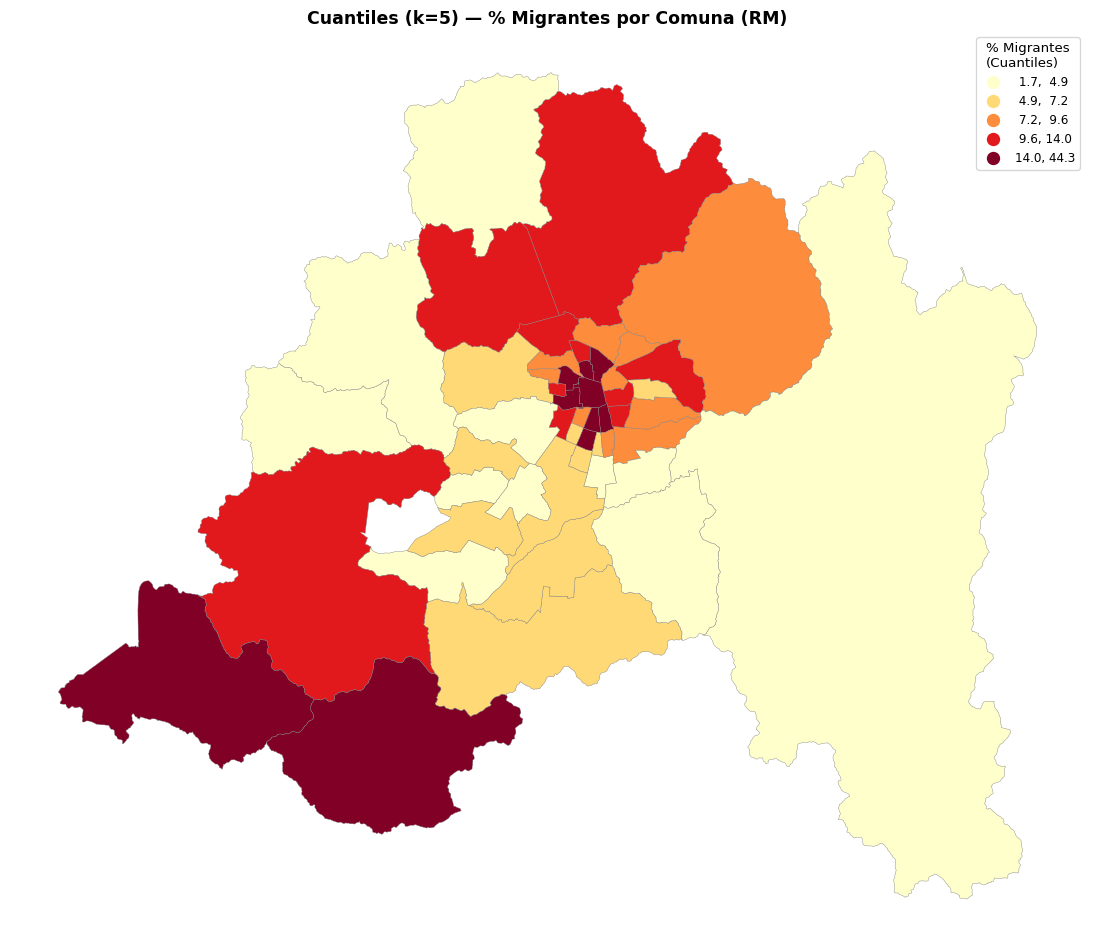

Quantiles

   Interval      Count
----------------------
[ 1.70,  4.90] |    11
( 4.90,  7.18] |    10
( 7.18,  9.57] |    10
( 9.57, 13.99] |    10
(13.99, 44.35] |    10


In [13]:
fig, ax = plt.subplots(1, figsize=(12, 10))
gdf_clean.plot(
    column="PCT_MIGRANTES",
    scheme="Quantiles",
    k=5,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"fmt": "{:.1f}", "title": "% Migrantes\n(Cuantiles)", "fontsize": 9},
    edgecolor="gray",
    linewidth=0.3,
    ax=ax,
)
ax.set_title("Cuantiles (k=5) — % Migrantes por Comuna (RM)", fontsize=13, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

q5 = mapclassify.Quantiles(gdf_clean["PCT_MIGRANTES"], k=5)
print(q5)

### 3.4 Fisher-Jenks (k=5)


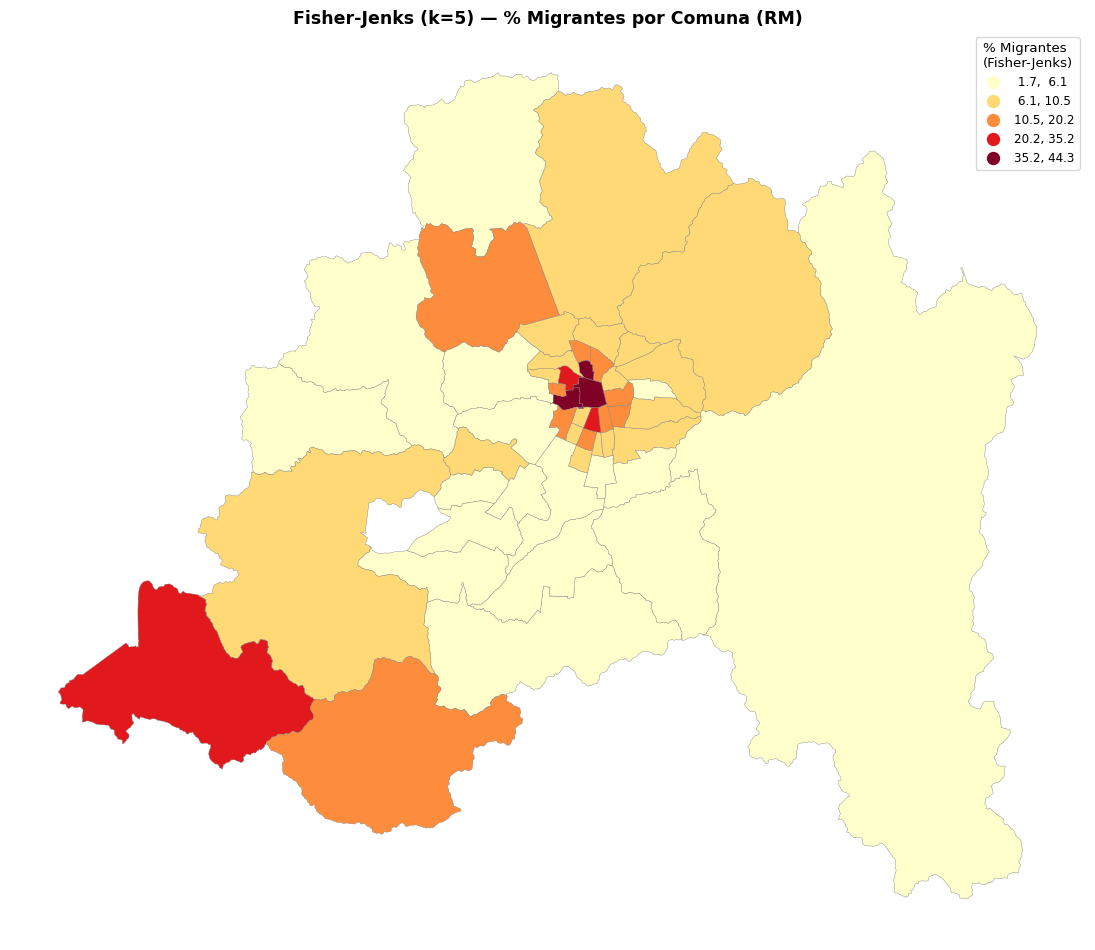

FisherJenks

   Interval      Count
----------------------
[ 1.70,  6.07] |    17
( 6.07, 10.48] |    18
(10.48, 20.17] |    10
(20.17, 35.20] |     3
(35.20, 44.35] |     3


In [14]:
fig, ax = plt.subplots(1, figsize=(12, 10))
gdf_clean.plot(
    column="PCT_MIGRANTES",
    scheme="FisherJenks",
    k=5,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"fmt": "{:.1f}", "title": "% Migrantes\n(Fisher-Jenks)", "fontsize": 9},
    edgecolor="gray",
    linewidth=0.3,
    ax=ax,
)
ax.set_title("Fisher-Jenks (k=5) — % Migrantes por Comuna (RM)", fontsize=13, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

fj5 = mapclassify.FisherJenks(gdf_clean["PCT_MIGRANTES"], k=5)
print(fj5)

### 3.5 Comparación lado a lado


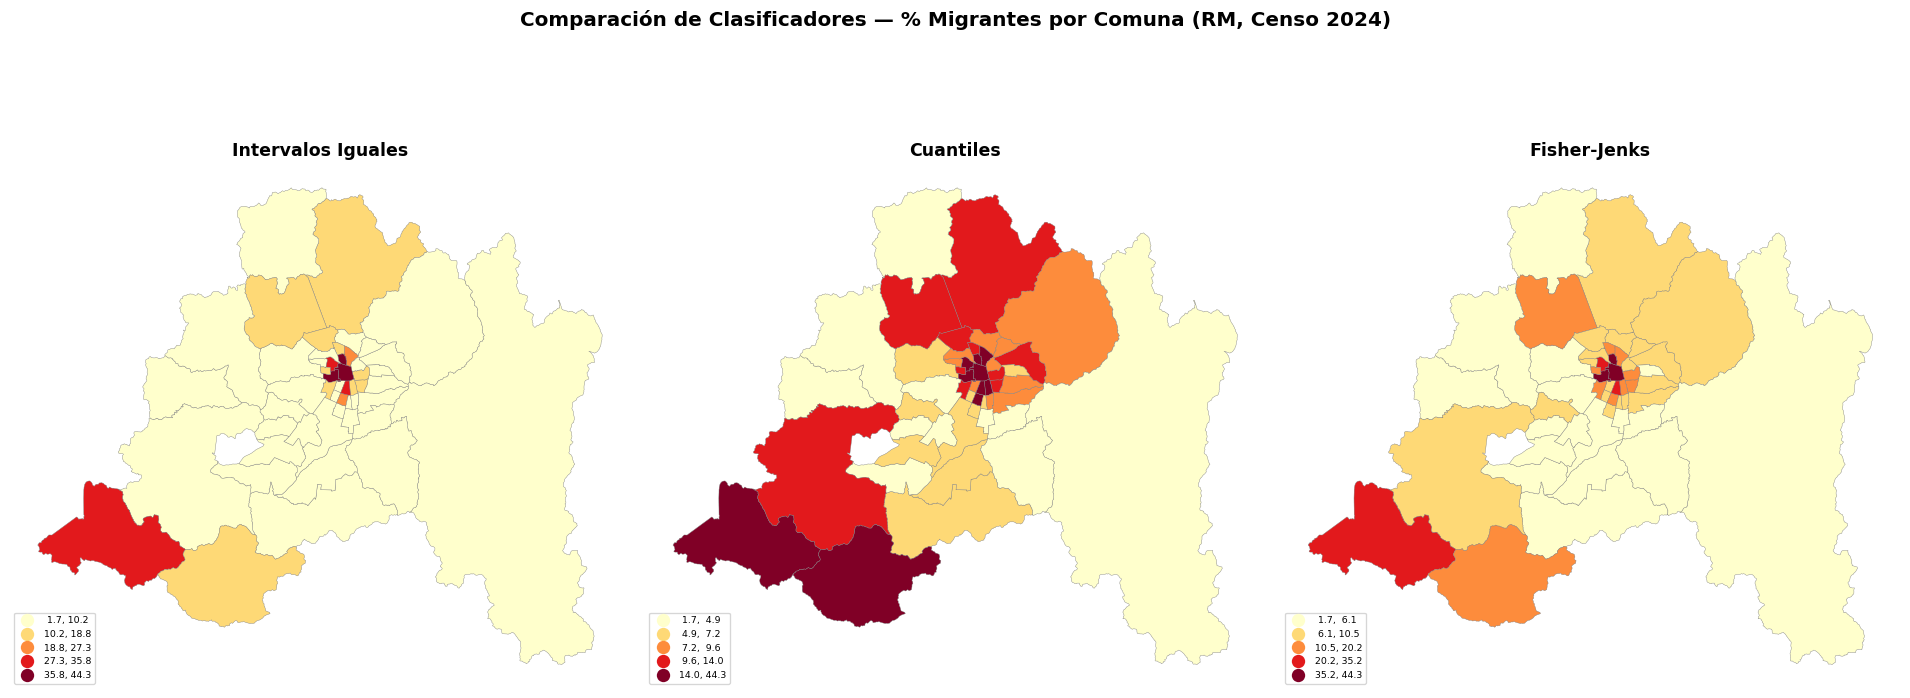

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

esquemas = [
    ("EqualInterval", "Intervalos Iguales"),
    ("Quantiles", "Cuantiles"),
    ("FisherJenks", "Fisher-Jenks"),
]

for ax, (scheme, titulo) in zip(axes, esquemas):
    gdf_clean.plot(
        column="PCT_MIGRANTES",
        scheme=scheme,
        k=5,
        cmap="YlOrRd",
        legend=True,
        legend_kwds={"fmt": "{:.1f}", "fontsize": 7, "loc": "lower left"},
        edgecolor="gray",
        linewidth=0.3,
        ax=ax,
    )
    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.set_axis_off()

plt.suptitle("Comparación de Clasificadores — % Migrantes por Comuna (RM, Censo 2024)", 
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.6 Comparación numérica: ADCM


In [16]:
print("ADCM por clasificador (menor = mejor ajuste):")
print("=" * 45)
for nombre, clf in sorted(
    {"Intervalos Iguales": ei5, "Cuantiles": q5, "Fisher-Jenks": fj5}.items(),
    key=lambda x: x[1].adcm
):
    print(f"  {nombre:25s}  ADCM = {clf.adcm:>8,.1f}")
print("=" * 45)

ADCM por clasificador (menor = mejor ajuste):
  Fisher-Jenks               ADCM =     67.2
  Intervalos Iguales         ADCM =     86.1
  Cuantiles                  ADCM =    132.2


---
## PARTE 4: Análisis e interpretación (15 minutos)
### 4.1 Heatmap comparativo


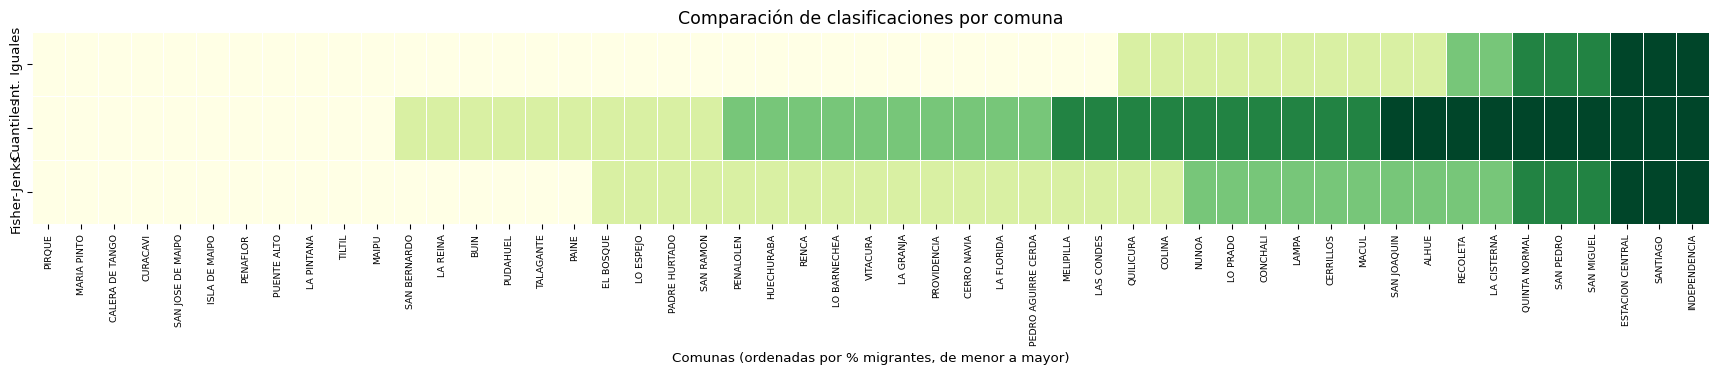

In [17]:
gdf_clean["Int. Iguales"] = ei5.yb
gdf_clean["Cuantiles"] = q5.yb
gdf_clean["Fisher-Jenks"] = fj5.yb

cols_clasif = ["Int. Iguales", "Cuantiles", "Fisher-Jenks"]

datos_heatmap = (
    gdf_clean.set_index("NOMBRE_NORM")
    .sort_values("PCT_MIGRANTES")
    [cols_clasif]
    .T
)

fig, ax = plt.subplots(1, figsize=(18, 4))
sns.heatmap(
    datos_heatmap, cmap="YlGn", cbar=False, ax=ax,
    linewidths=0.5, linecolor="white"
)
ax.set_xlabel("Comunas (ordenadas por % migrantes, de menor a mayor)")
ax.set_ylabel("")
ax.set_title("Comparación de clasificaciones por comuna", fontsize=13)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

### 4.2 Mapa por país de origen: venezolanos


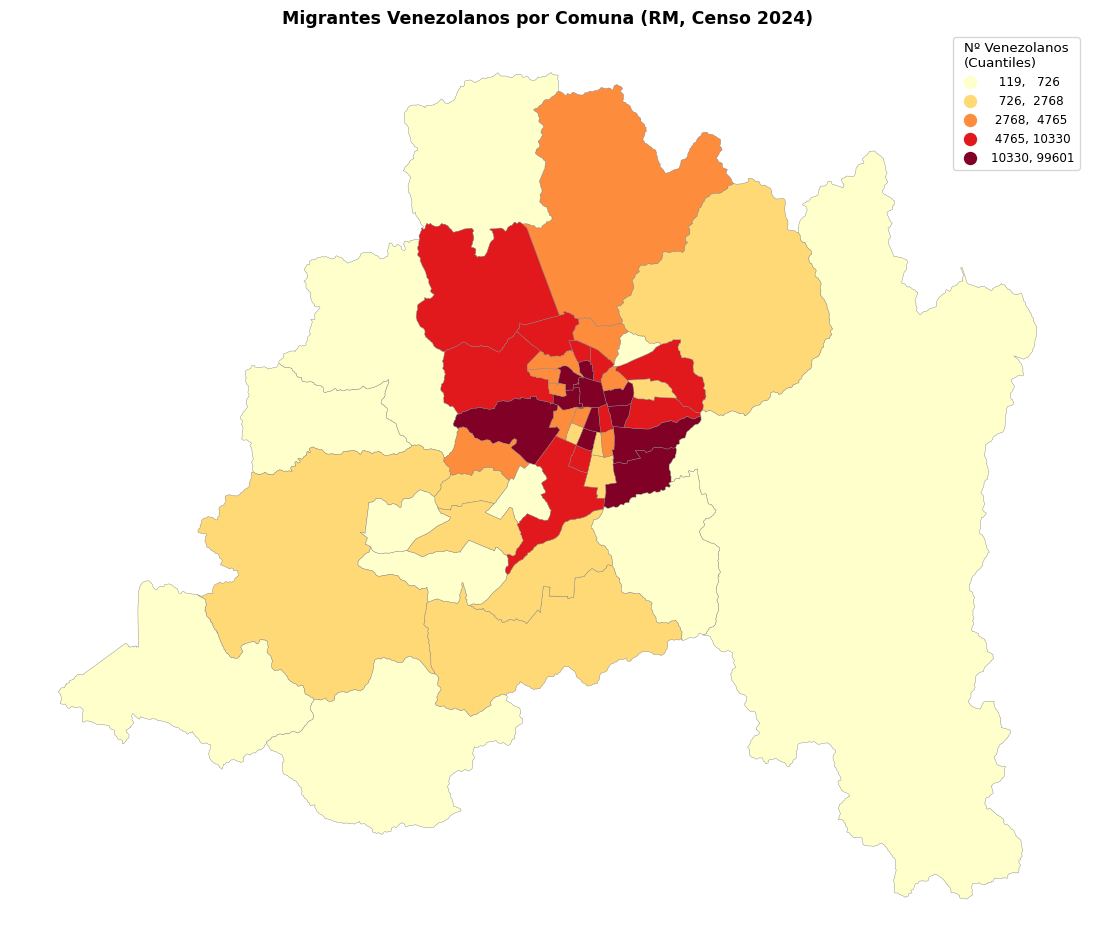

In [18]:
venezolanos = migrant_reg_counts[
    migrant_reg_counts["CONTINENTE"] == "Venezuela"
].copy()

venezolanos = venezolanos.groupby("COMUNA")["Nº_MIGRANTES"].sum().reset_index()
venezolanos.columns = ["COMUNA", "VENEZOLANOS"]

gdf_ven = comunas_gdf.copy()
gdf_ven["NOMBRE_NORM"] = gdf_ven["NOM_COMUNA"].apply(normalizar)
venezolanos["NOMBRE_NORM"] = venezolanos["COMUNA"].apply(normalizar)
gdf_ven = gdf_ven.merge(venezolanos, on="NOMBRE_NORM", how="left")

fig, ax = plt.subplots(1, figsize=(12, 10))
gdf_ven.dropna(subset=["VENEZOLANOS"]).plot(
    column="VENEZOLANOS",
    scheme="Quantiles",
    k=5,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"fmt": "{:.0f}", "title": "Nº Venezolanos\n(Cuantiles)", "fontsize": 9},
    edgecolor="gray",
    linewidth=0.3,
    ax=ax,
)
ax.set_title("Migrantes Venezolanos por Comuna (RM, Censo 2024)", fontsize=13, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 4.3 Preguntas de análisis — RESPUESTAS

---

**Pregunta 1:** ¿Qué comunas concentran la mayor proporción de migrantes? ¿Coincide con lo que conoces de Santiago? ¿Por qué crees que estas comunas atraen más migración?

**Respuesta:**

Las comunas con mayor porcentaje de migrantes son **Independencia (44.3%)**, **Santiago (42.7%)** y **Estación Central (38.6%)**, seguidas por San Miguel (~35%) y Quinta Normal (~27%). Esto coincide con lo que se observa en Santiago: son comunas del **centro y pericentro** que comparten características que atraen migración:

- **Vivienda más accesible:** alta oferta de arriendos en departamentos pequeños y piezas, con precios más bajos que comunas del sector oriente.
- **Conectividad:** cercanía al Metro y transporte público, lo que facilita el acceso al empleo sin necesidad de auto.
- **Redes migrantes preexistentes:** una vez que se establece una comunidad migrante en una comuna, esta atrae más migración por redes de apoyo, comercio étnico y familiaridad cultural.
- **Oferta laboral:** cercanía a zonas comerciales y de servicios del centro de Santiago.

Las comunas periféricas rurales (Alhué, San Pedro, María Pinto, Pirque) tienen los porcentajes más bajos, lo cual también es esperable por su lejanía y menor dinamismo económico urbano.


**Pregunta 2:** Compara los tres mapas. ¿En qué comunas los clasificadores "discrepan" más? ¿Por qué ocurre esto?

**Respuesta:**

Las mayores discrepancias se observan en las comunas del **rango medio-alto** (entre ~10% y ~20% de migrantes), como **Quilicura, Recoleta, Providencia, Ñuñoa y Quinta Normal**:

- **Intervalos Iguales** mete 33 de 51 comunas en la primera clase (1.7%–10.2%), haciendo que comunas con realidades muy distintas (Alhué con 1.7% y Maipú con ~9%) se vean iguales. A la vez, separa bien los extremos altos.
- **Cuantiles** fuerza 10-11 comunas por clase, lo que genera un mapa visualmente más "lleno de color" pero agrupa en la última clase a comunas que van de 14% a 44%, una diferencia enorme que queda oculta bajo el mismo color.
- **Fisher-Jenks** logra el mejor balance: identifica los 3 outliers altos (Independencia, Santiago, Estación Central) como clase propia y separa mejor el rango medio.

La discrepancia ocurre porque cada clasificador prioriza un criterio distinto: ancho constante, conteo equilibrado, o varianza mínima. Las comunas que están "entre medio" son las más sensibles a estos criterios.


**Pregunta 3:** Si tuvieras que presentar estos datos en un informe para una política pública sobre integración de migrantes, ¿qué clasificador elegirías y por qué?

**Respuesta:**

Elegiría **Fisher-Jenks** (ADCM = 67.2, el más bajo) por las siguientes razones:

1. **Identifica claramente las comunas prioritarias:** separa Independencia, Santiago y Estación Central como el grupo de mayor concentración migratoria, lo cual permite focalizar recursos de integración.
2. **Diferencia el rango medio:** no agrupa comunas del 6% con comunas del 20% en la misma clase, a diferencia de Intervalos Iguales.
3. **No oculta la brecha:** a diferencia de Cuantiles, no mete el 14% junto al 44% en la misma clase.

Sin embargo, si el objetivo fuera **comparar comunas entre sí** (ej: ranking de prioridad), Cuantiles podría ser útil porque genera grupos de tamaño similar, facilitando la asignación equitativa de recursos. La elección depende del mensaje que se quiera comunicar: si es "dónde está el problema más agudo" → Fisher-Jenks; si es "cómo repartir recursos equitativamente" → Cuantiles.


**Pregunta 4:** Compara el mapa del porcentaje total de migrantes con el mapa de venezolanos en números absolutos. ¿Qué historia diferente cuenta cada uno?

**Respuesta:**

Cuentan historias complementarias pero distintas:

- El mapa de **% total de migrantes** muestra la **intensidad relativa** de la migración respecto a la población local. Comunas pequeñas como Independencia (115.000 hab.) aparecen con valores altos porque, aunque tienen menos migrantes en total que Santiago, representan una fracción mayor de su población. Esto es útil para entender **presión sobre servicios locales** (salud, educación, vivienda) y el grado de transformación demográfica de cada comuna.

- El mapa de **venezolanos en números absolutos** muestra **dónde hay más personas venezolanas**, punto. Santiago lidera por lejos (tiene la mayor población total de la RM). Comunas grandes como Maipú o Puente Alto aparecen con más peso que en el mapa de porcentajes. Este mapa es útil para planificar **servicios específicos** (consulados, organizaciones de apoyo, oferta cultural).

**¿Cuándo usar cada uno?**
- **Porcentajes:** cuando interesa la proporción y el impacto relativo (políticas de integración, planificación de servicios per cápita).
- **Números absolutos:** cuando interesa la demanda total (dimensionar presupuestos, ubicar servicios físicos, estimar volúmenes).

Lo ideal es presentar ambos, porque un porcentaje alto en una comuna pequeña y un número absoluto alto en una comuna grande requieren respuestas de política pública diferentes.


---

### Referencias

- Clase 5: Mapas Coropléticos (basada en Rey, Arribas-Bel y Wolf, 2020. *Geographic Data Science with Python*).
- Datos: [Censo 2024 - INE Chile](https://censo2024.ine.gob.cl/)
- Procesamiento original: [daniopitz/censo2024](https://github.com/daniopitz/censo2024)
